In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits import mplot3d

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [88]:
# Load Dataset

df = pd.read_excel("Iris.xlsx")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [89]:
# Removing null

print("Before : \n")
print(df.isnull().sum())

for i in df:
  if df[i].dtype in ['float64', 'int64']:
    df[i] = df[i].fillna(df[i].median())

print("\nAfter : \n")
print(df.isnull().sum())

Before : 

sepal_length    0
sepal_width     3
petal_length    3
petal_width     0
species         0
dtype: int64

After : 

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [90]:
# Select Two Classes

df = df[df['species'] != 'Iris-virginica']

print(df['species'].value_counts())

species
Iris-setosa        50
Iris-versicolor    50
Name: count, dtype: int64


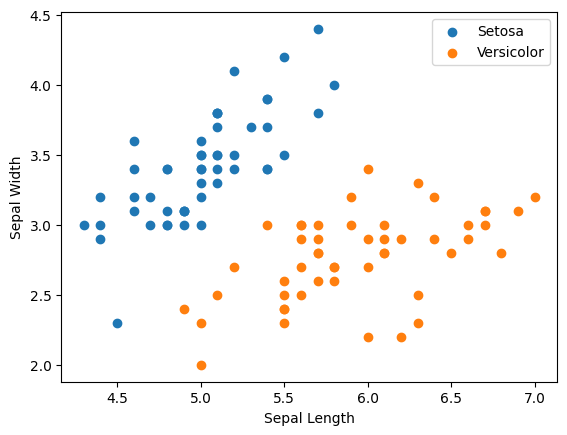

In [91]:
# Plot Dataset

X = df.drop('species', axis=1).values
y = df['species'].values


y_binary = np.where(y == 'Iris-setosa', 1, -1)

plt.scatter(
    X[y_binary == 1, 0],
    X[y_binary == 1, 1],
    label='Setosa'
)

plt.scatter(
    X[y_binary == -1, 0],
    X[y_binary == -1, 1],
    label='Versicolor'
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()
plt.show()


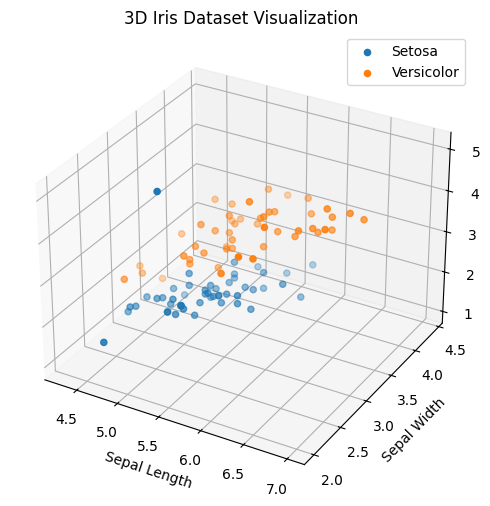

In [92]:
# 3D Plot

from mpl_toolkits import mplot3d

fig = plt.figure(figsize=(8,6))

ax = plt.axes(projection='3d')

# Setosa
ax.scatter3D(
    X[y_binary == 1, 0],
    X[y_binary == 1, 1],
    X[y_binary == 1, 2],
    label='Setosa'
)

# Versicolor
ax.scatter3D(
    X[y_binary == -1, 0],
    X[y_binary == -1, 1],
    X[y_binary == -1, 2],
    label='Versicolor'
)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')

ax.set_title('3D Iris Dataset Visualization')

plt.legend()

plt.show()

In [93]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

print(X[:5])

[[-0.5810659   0.86141152 -1.03209367 -1.03824799]
 [-0.89430898 -0.19423985 -1.03209367 -1.03824799]
 [-1.20755205  0.2280207  -1.10140822 -1.03824799]
 [-1.36417359  0.01689042 -0.96277912 -1.03824799]
 [-0.73768744  1.0725418  -1.03209367 -1.03824799]]


In [94]:
# split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)



(80, 4)
(20, 4)


In [95]:
# Perceptron class

class Perceptron:

    def __init__(self, learning_rate=0.01, n_iters=100):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.errors = []

    def activation(self, x):
        return np.where(x >= 0, 1, -1)

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):

            error_count = 0

            for idx, x_i in enumerate(X):

                linear_output = np.dot(x_i, self.weights) + self.bias

                y_pred = self.activation(linear_output)

                update = self.lr * (y[idx] - y_pred)

                self.weights += update * x_i
                self.bias += update

                if update != 0:
                    error_count += 1

            self.errors.append(error_count)

    def predict(self, X):

        linear_output = np.dot(X, self.weights) + self.bias

        return self.activation(linear_output)

In [96]:
# Train Model

model = Perceptron(
    learning_rate=0.01,
    n_iters=100
)

model.fit(X_train, y_train)


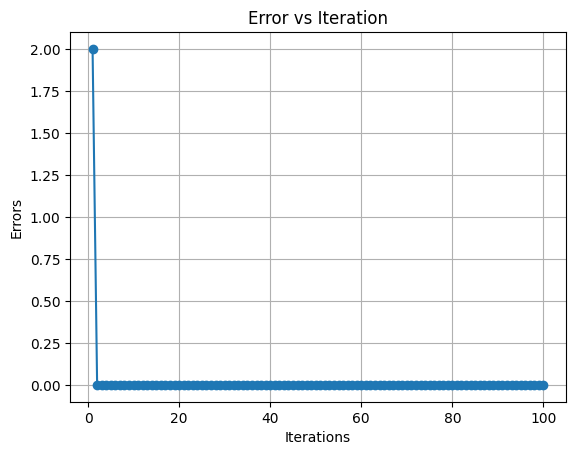

In [97]:
# Plot Errors

plt.plot(
    range(1, len(model.errors)+1),
    model.errors,
    marker='o'
)

plt.xlabel("Iterations")
plt.ylabel("Errors")
plt.title("Error vs Iteration")
plt.grid(True)

plt.show()

In [98]:
# Predict
y_pred = model.predict(X_test)

print(y_pred)

[-1 -1 -1  1  1  1  1 -1  1  1  1  1 -1  1 -1  1 -1 -1  1  1]


In [99]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy * 100, "%")

Accuracy = 100.0 %
